In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

RESULTS_DIR = Path('results')
PARTS = ['task', 'mod', 'pre', 'post', 'err']

In [2]:
def parse_tag(tag):
    """Return dict {part: bool} — True if part is enabled in this ablation."""
    disabled = set(re.findall(r'no_([a-z]+)', tag))
    return {p: (p not in disabled) for p in PARTS}

def extract_interaction_metrics(interactions):
    """Aggregate cost/token/time metrics across all interactions."""
    total_cost = 0.0
    total_prompt_tokens = 0
    total_completion_tokens = 0
    total_tokens = 0
    total_verification_time = 0.0
    total_ai_time = 0.0
    n_suggestions = 0
    n_accepted = 0
    n_rejected = 0

    for ix in interactions:
        total_verification_time += ix.get('verification_time_seconds', 0.0)
        total_ai_time           += ix.get('ai_request_time_seconds', 0.0)
        for sg in ix.get('suggestions', []):
            total_cost              += sg.get('cost', 0.0)
            total_prompt_tokens     += sg.get('prompt_tokens', 0)
            total_completion_tokens += sg.get('completion_tokens', 0)
            total_tokens            += sg.get('total_tokens', 0)
            n_suggestions += 1
            if sg.get('accepted'):
                n_accepted += 1
            else:
                n_rejected += 1

    return {
        'total_cost':               total_cost,
        'total_prompt_tokens':      total_prompt_tokens,
        'total_completion_tokens':  total_completion_tokens,
        'total_tokens':             total_tokens,
        'total_verification_time':  total_verification_time,
        'total_ai_time':            total_ai_time,
        'n_suggestions':            n_suggestions,
        'n_accepted':               n_accepted,
        'n_rejected':               n_rejected,
    }

records = []
for dataset_dir in sorted(RESULTS_DIR.iterdir()):
    if not dataset_dir.is_dir():
        continue
    for model_dir in sorted(dataset_dir.iterdir()):
        if not model_dir.is_dir():
            continue
        for jf in sorted(model_dir.glob('*.jsonl')):
            tag = jf.stem
            parts = parse_tag(tag)
            n_enabled = sum(parts.values())
            with open(jf) as f:
                for line in f:
                    rec = json.loads(line)
                    rec['dataset']      = dataset_dir.name
                    rec['model_slug']   = model_dir.name
                    rec['ablation_tag'] = tag
                    rec['n_parts']      = n_enabled
                    for p in PARTS:
                        rec[f'has_{p}'] = parts[p]
                    metrics = extract_interaction_metrics(rec.get('interactions', []))
                    rec.update(metrics)
                    rec.setdefault('total_elapsed_time_seconds', 0.0)
                    records.append(rec)

df = pd.DataFrame(records)
df['class_feature'] = df['class_name'] + '.' + df['feature_name']

print(f'Total records : {len(df)}')
print(f'Datasets      : {sorted(df["dataset"].unique())}')
print(f'Model slugs   : {sorted(df["model_slug"].unique())}')
print(f'Ablation tags : {len(df["ablation_tag"].unique())} unique')
print(f'Features      : {df["class_feature"].nunique()} unique')
print(f'Total cost    : ${df["total_cost"].sum():.6f}')
print(f'Total tokens  : {df["total_tokens"].sum():,}')

Total records : 16
Datasets      : ['buggy-java-jml-eiffel', 'maple-recursive']
Model slugs   : ['liquid_lfm-2.5-1.2b-instruct_free', 'poolside_laguna-xs.2_free']
Ablation tags : 2 unique
Features      : 4 unique
Total cost    : $0.000000
Total tokens  : 241,620


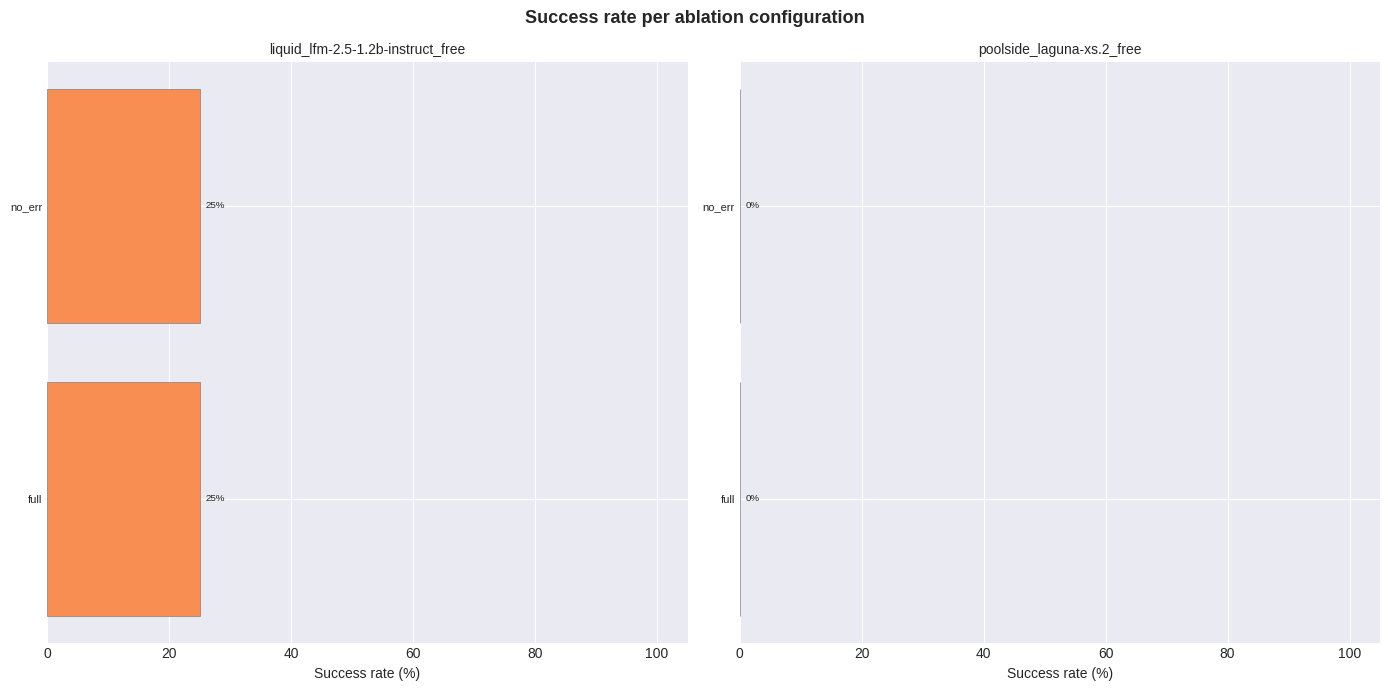

In [3]:
abl = (
    df.groupby(['model_slug', 'ablation_tag', 'n_parts'])
    .agg(success_rate=('success', 'mean'), n=('success', 'count'))
    .reset_index()
    .sort_values(['model_slug', 'success_rate'], ascending=[True, False])
)

models = sorted(df['model_slug'].unique())
fig, axes = plt.subplots(1, len(models), figsize=(max(14, 6 * len(models)), 7), sharey=False)
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    sub = abl[abl['model_slug'] == model].copy()
    colors = plt.cm.RdYlGn(sub['success_rate'].values)
    ax.barh(range(len(sub)), sub['success_rate'] * 100, color=colors, edgecolor='grey', linewidth=0.5)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['ablation_tag'], fontsize=8)
    ax.set_xlabel('Success rate (%)')
    ax.set_title(model, fontsize=10)
    ax.set_xlim(0, 105)
    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(row['success_rate'] * 100 + 1, i, f"{row['success_rate']*100:.0f}%",
                va='center', fontsize=7)

fig.suptitle('Success rate per ablation configuration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

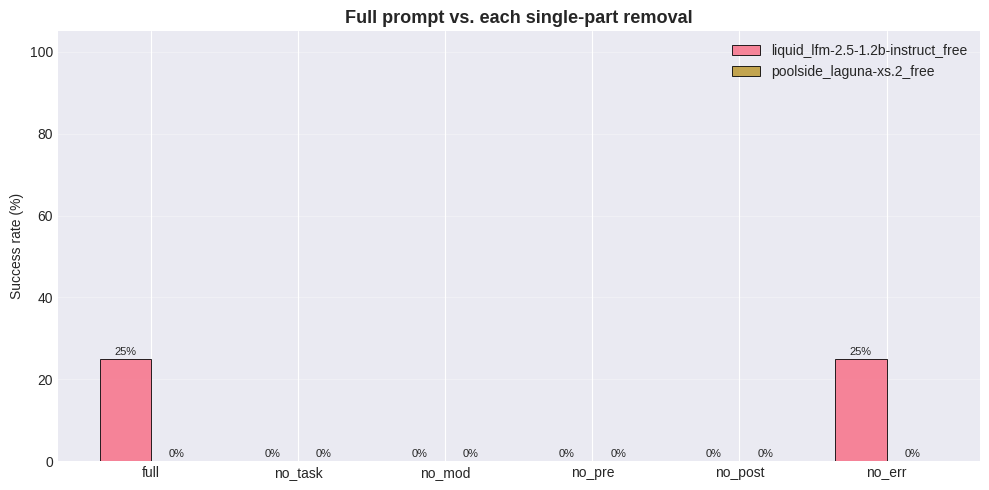

In [4]:
SINGLE_REMOVALS = ['full'] + [f'no_{p}' for p in PARTS]
single = abl[abl['ablation_tag'].isin(SINGLE_REMOVALS)].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(SINGLE_REMOVALS))
width = 0.35

for i, model in enumerate(models):
    sub = single[single['model_slug'] == model].set_index('ablation_tag')
    rates = [sub.loc[tag, 'success_rate'] * 100 if tag in sub.index else 0
             for tag in SINGLE_REMOVALS]
    offset = (i - len(models) / 2 + 0.5) * width
    bars = ax.bar(x + offset, rates, width, label=model, alpha=0.85, edgecolor='black', linewidth=0.7)
    for bar, val in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(SINGLE_REMOVALS, fontsize=10)
ax.set_ylabel('Success rate (%)')
ax.set_ylim(0, 105)
ax.set_title('Full prompt vs. each single-part removal', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Marginal effect of each prompt part (positive = part helps):
                            model part  enabled  disabled  delta
liquid_lfm-2.5-1.2b-instruct_free task     25.0       NaN    NaN
liquid_lfm-2.5-1.2b-instruct_free  mod     25.0       NaN    NaN
liquid_lfm-2.5-1.2b-instruct_free  pre     25.0       NaN    NaN
liquid_lfm-2.5-1.2b-instruct_free post     25.0       NaN    NaN
liquid_lfm-2.5-1.2b-instruct_free  err     25.0      25.0    0.0
        poolside_laguna-xs.2_free task      0.0       NaN    NaN
        poolside_laguna-xs.2_free  mod      0.0       NaN    NaN
        poolside_laguna-xs.2_free  pre      0.0       NaN    NaN
        poolside_laguna-xs.2_free post      0.0       NaN    NaN
        poolside_laguna-xs.2_free  err      0.0       0.0    0.0


/tmp/ipykernel_13914/2876329999.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


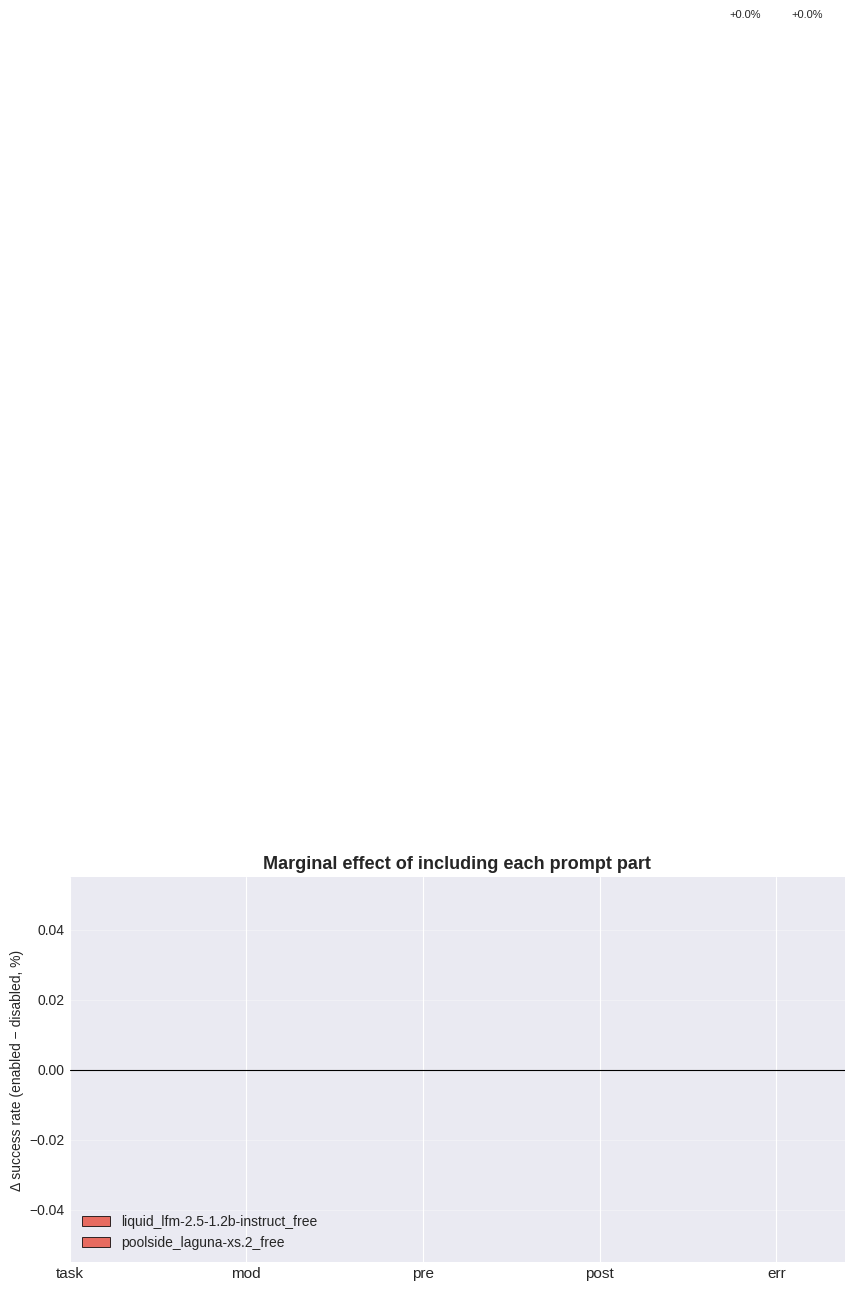

In [5]:
marginal_rows = []
for model in models:
    sub = abl[abl['model_slug'] == model].copy()
    part_flags = (
        df[df['model_slug'] == model]
        .groupby('ablation_tag')[[f'has_{p}' for p in PARTS]]
        .first()
        .reset_index()
    )
    sub = sub.merge(part_flags, on='ablation_tag')
    for p in PARTS:
        enabled  = sub[sub[f'has_{p}']]['success_rate'].mean()
        disabled = sub[~sub[f'has_{p}']]['success_rate'].mean()
        marginal_rows.append({'model': model, 'part': p,
                               'enabled': enabled * 100, 'disabled': disabled * 100,
                               'delta': (enabled - disabled) * 100})

mg = pd.DataFrame(marginal_rows)
print('Marginal effect of each prompt part (positive = part helps):')
print(mg.to_string(index=False, float_format='{:.1f}'.format))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(PARTS))
width = 0.35

for i, model in enumerate(models):
    sub = mg[mg['model'] == model]
    deltas = sub.set_index('part').loc[PARTS, 'delta'].values
    offset = (i - len(models) / 2 + 0.5) * width
    colors = ['#27ae60' if d >= 0 else '#e74c3c' for d in deltas]
    bars = ax.bar(x + offset, deltas, width, label=model, color=colors, alpha=0.8,
                  edgecolor='black', linewidth=0.7)
    for bar, val in zip(bars, deltas):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + (0.3 if val >= 0 else -1.5),
                f'{val:+.1f}%', ha='center', va='bottom', fontsize=8)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(PARTS, fontsize=11)
ax.set_ylabel('\u0394 success rate (enabled \u2212 disabled, %)')
ax.set_title('Marginal effect of including each prompt part', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

/usr/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/tmp/ipykernel_13914/1886339604.py:36: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_13914/1886339604.py:36: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


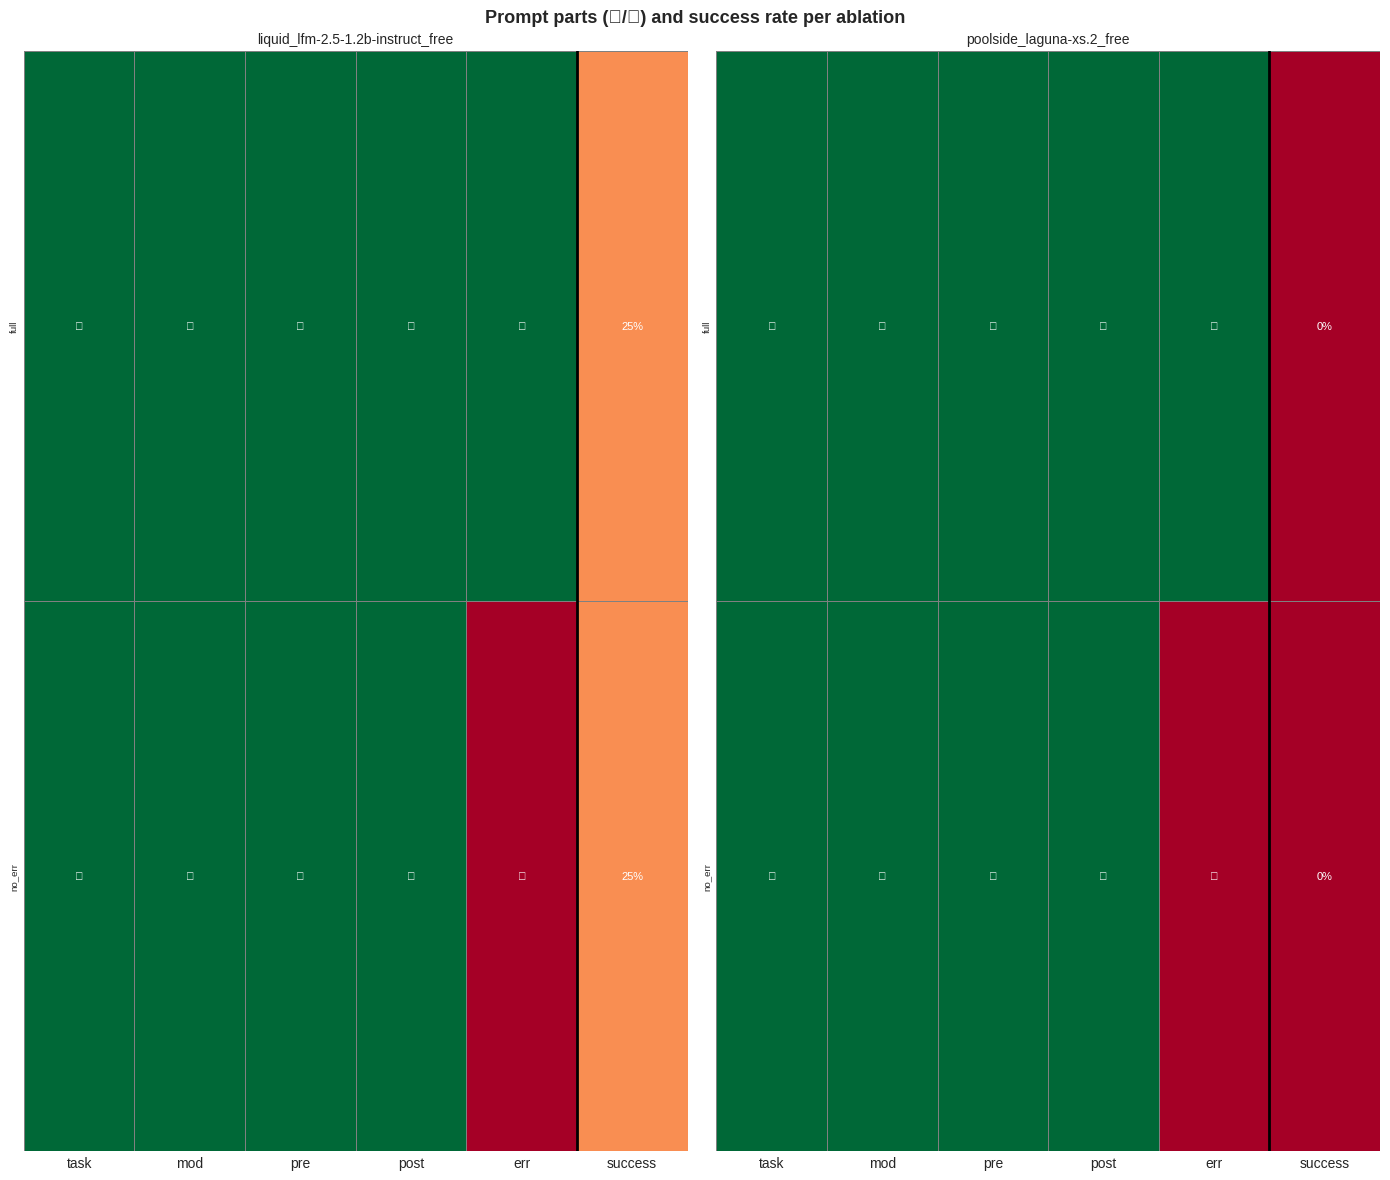

In [6]:
fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 12))
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    sub = abl[abl['model_slug'] == model].copy()
    part_flags = (
        df[df['model_slug'] == model]
        .groupby('ablation_tag')[[f'has_{p}' for p in PARTS]]
        .first()
        .reset_index()
    )
    sub = sub.merge(part_flags, on='ablation_tag')
    sub = sub.sort_values(['n_parts', 'success_rate'], ascending=[False, False])

    mat   = sub[[f'has_{p}' for p in PARTS]].astype(float).values
    rates = sub['success_rate'].values
    combined = np.hstack([mat, rates.reshape(-1, 1)])

    annot = np.empty((len(sub), 6), dtype=object)
    for r in range(len(sub)):
        for c in range(5):
            annot[r, c] = '\u2713' if mat[r, c] == 1 else '\u2717'
        annot[r, 5] = f'{rates[r]*100:.0f}%'

    sns.heatmap(combined, ax=ax, xticklabels=PARTS + ['success'],
                yticklabels=sub['ablation_tag'].values, cmap='RdYlGn',
                vmin=0, vmax=1, linewidths=0.5, linecolor='grey',
                annot=annot, fmt='', annot_kws={'size': 8}, cbar=False)
    ax.set_title(model, fontsize=10)
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', labelsize=10)
    ax.axvline(5, color='black', linewidth=2)

fig.suptitle('Prompt parts (\u2713/\u2717) and success rate per ablation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

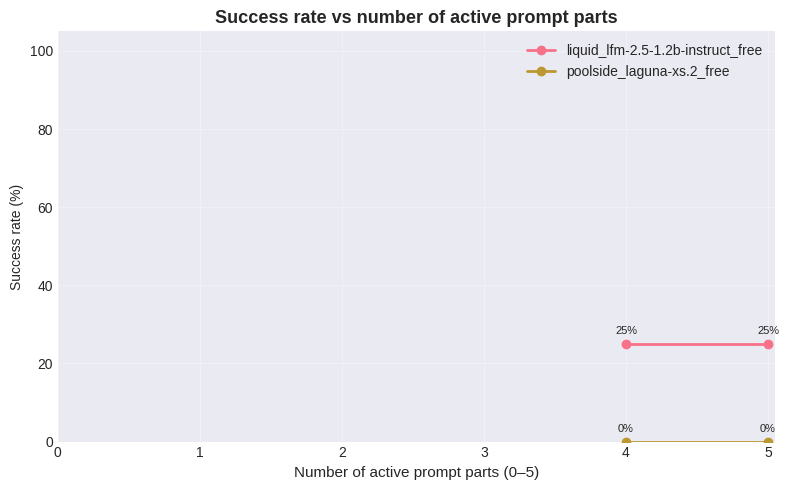

                       model_slug  n_parts  success_rate  n
liquid_lfm-2.5-1.2b-instruct_free        4          0.25  4
liquid_lfm-2.5-1.2b-instruct_free        5          0.25  4
        poolside_laguna-xs.2_free        4          0.00  4
        poolside_laguna-xs.2_free        5          0.00  4


In [7]:
by_nparts = (
    df.groupby(['model_slug', 'n_parts'])
    .agg(success_rate=('success', 'mean'), n=('success', 'count'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
for model in models:
    sub = by_nparts[by_nparts['model_slug'] == model].sort_values('n_parts')
    ax.plot(sub['n_parts'], sub['success_rate'] * 100, marker='o', label=model, linewidth=2)
    for _, row in sub.iterrows():
        ax.annotate(f"{row['success_rate']*100:.0f}%",
                    xy=(row['n_parts'], row['success_rate'] * 100),
                    xytext=(0, 7), textcoords='offset points', ha='center', fontsize=8)

ax.set_xlabel('Number of active prompt parts (0\u20135)', fontsize=11)
ax.set_ylabel('Success rate (%)')
ax.set_xticks(range(6))
ax.set_ylim(0, 105)
ax.set_title('Success rate vs number of active prompt parts', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(by_nparts.to_string(index=False))

Timing summary per model:
                       model_slug  n  median_elapsed  mean_elapsed  median_verif  median_ai  total_elapsed_h
liquid_lfm-2.5-1.2b-instruct_free  8           43.01         41.57         26.70      11.15             0.09
        poolside_laguna-xs.2_free  8          114.67        227.77         27.63      83.12             0.51


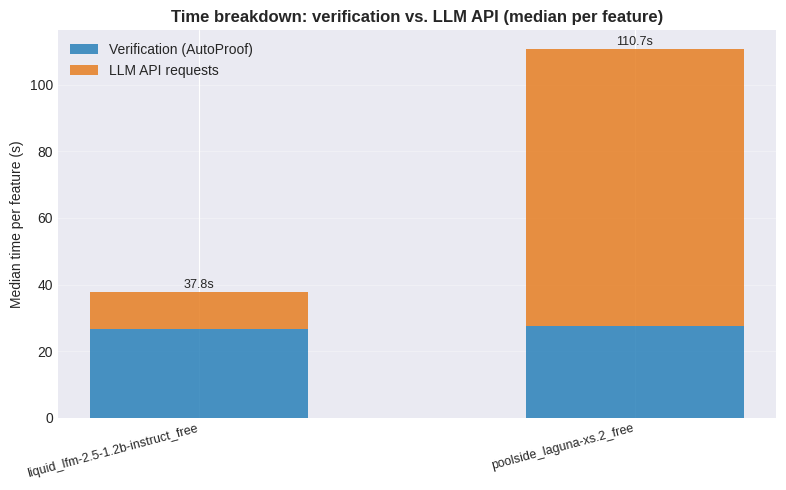

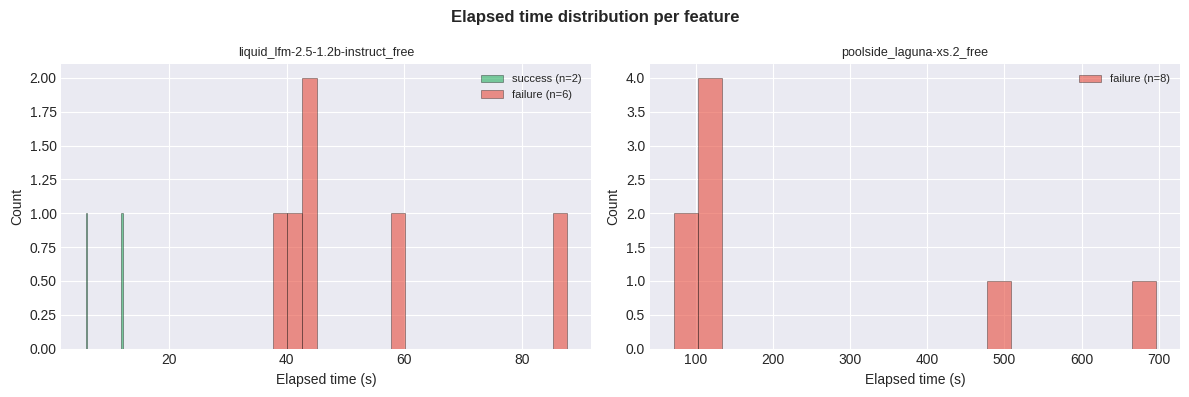

In [8]:
timing = (
    df.groupby('model_slug')
    .agg(
        n=('success', 'count'),
        median_elapsed=('total_elapsed_time_seconds', 'median'),
        mean_elapsed=('total_elapsed_time_seconds', 'mean'),
        median_verif=('total_verification_time', 'median'),
        median_ai=('total_ai_time', 'median'),
        total_elapsed_h=('total_elapsed_time_seconds', lambda s: s.sum() / 3600),
    )
    .reset_index()
)
print('Timing summary per model:')
print(timing.to_string(index=False, float_format='{:.2f}'.format))

fig, ax = plt.subplots(figsize=(max(8, 3 * len(models)), 5))
x = np.arange(len(models))
w = 0.5
verif_vals = timing.set_index('model_slug').loc[models, 'median_verif'].values
ai_vals    = timing.set_index('model_slug').loc[models, 'median_ai'].values

ax.bar(x, verif_vals, w, label='Verification (AutoProof)', color='#2980b9', alpha=0.85)
ax.bar(x, ai_vals, w, bottom=verif_vals, label='LLM API requests', color='#e67e22', alpha=0.85)
for i, (v, a) in enumerate(zip(verif_vals, ai_vals)):
    ax.text(i, v + a + 0.2, f'{v+a:.1f}s', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Median time per feature (s)')
ax.set_title('Time breakdown: verification vs. LLM API (median per feature)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 4), sharey=False)
if len(models) == 1:
    axes = [axes]
for ax, model in zip(axes, models):
    sub = df[df['model_slug'] == model]
    for success, label, color in [(True, 'success', '#27ae60'), (False, 'failure', '#e74c3c')]:
        vals = sub[sub['success'] == success]['total_elapsed_time_seconds'].dropna()
        if len(vals):
            ax.hist(vals, bins=20, alpha=0.6, label=f'{label} (n={len(vals)})',
                    color=color, edgecolor='black', linewidth=0.4)
    ax.set_xlabel('Elapsed time (s)')
    ax.set_ylabel('Count')
    ax.set_title(model, fontsize=9)
    ax.legend(fontsize=8)
fig.suptitle('Elapsed time distribution per feature', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Cost & token summary per (model, ablation):
                       model_slug ablation_tag  n  success_rate  total_cost  mean_cost_per_feature  mean_tokens  mean_suggestions  mean_accepted
liquid_lfm-2.5-1.2b-instruct_free         full  4        0.2500      0.0000                 0.0000   10569.5000            8.2500         1.2500
liquid_lfm-2.5-1.2b-instruct_free       no_err  4        0.2500      0.0000                 0.0000    6605.0000            7.7500         1.0000
        poolside_laguna-xs.2_free         full  4        0.0000      0.0000                 0.0000   24024.7500            9.7500         0.0000
        poolside_laguna-xs.2_free       no_err  4        0.0000      0.0000                 0.0000   19205.7500           10.0000         0.0000


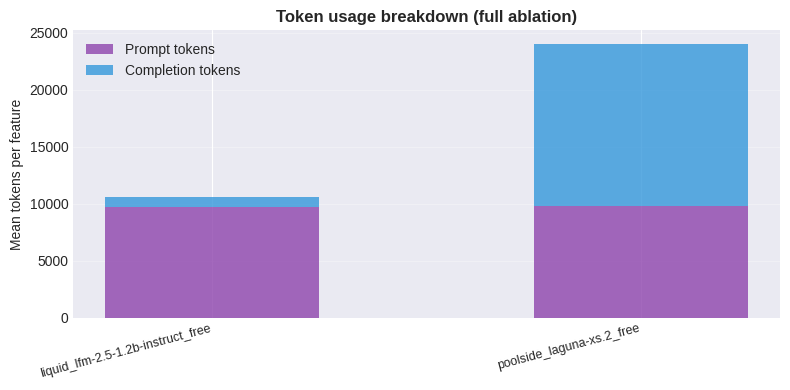

All models are free-tier (cost = $0). No cost heatmap to show.


In [9]:
cost_summary = (
    df.groupby(['model_slug', 'ablation_tag'])
    .agg(
        n=('success', 'count'),
        success_rate=('success', 'mean'),
        total_cost=('total_cost', 'sum'),
        mean_cost_per_feature=('total_cost', 'mean'),
        total_tokens=('total_tokens', 'sum'),
        mean_tokens=('total_tokens', 'mean'),
        mean_prompt_tokens=('total_prompt_tokens', 'mean'),
        mean_completion_tokens=('total_completion_tokens', 'mean'),
        mean_suggestions=('n_suggestions', 'mean'),
        mean_accepted=('n_accepted', 'mean'),
    )
    .reset_index()
)
print('Cost & token summary per (model, ablation):')
print(cost_summary[['model_slug', 'ablation_tag', 'n', 'success_rate',
                     'total_cost', 'mean_cost_per_feature',
                     'mean_tokens', 'mean_suggestions', 'mean_accepted']]
      .to_string(index=False, float_format='{:.4f}'.format))

full_rows = df[df['ablation_tag'] == 'full']
if not full_rows.empty:
    tok = (
        full_rows.groupby('model_slug')
        .agg(mean_prompt=('total_prompt_tokens', 'mean'),
             mean_completion=('total_completion_tokens', 'mean'))
        .reindex(models)
    )
    fig, ax = plt.subplots(figsize=(max(8, 3 * len(models)), 4))
    x = np.arange(len(models))
    w = 0.5
    ax.bar(x, tok['mean_prompt'].values, w, label='Prompt tokens', color='#8e44ad', alpha=0.8)
    ax.bar(x, tok['mean_completion'].values, w,
           bottom=tok['mean_prompt'].values, label='Completion tokens', color='#3498db', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Mean tokens per feature')
    ax.set_title('Token usage breakdown (full ablation)', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

paid = cost_summary[cost_summary['total_cost'] > 0]
if not paid.empty:
    pivot = paid.pivot(index='ablation_tag', columns='model_slug',
                       values='mean_cost_per_feature').fillna(0)
    fig, ax = plt.subplots(figsize=(max(6, 3 * len(pivot.columns)), max(4, 0.4 * len(pivot))))
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', fmt='.5f', annot=True,
                linewidths=0.5, linecolor='grey')
    ax.set_title('Mean cost per feature (USD) \u2014 paid models only', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('All models are free-tier (cost = $0). No cost heatmap to show.')

In [12]:
import html as _html
from IPython.display import HTML, display

FILTER_MODEL    = None   # e.g. 'poolside_laguna-xs.2_free'
FILTER_ABLATION = 'full' # e.g. 'full', 'no_task', None for any
SHOW_SUCCESS    = True  # set True to browse successes
SHOW_INDEX      = -1      # which record to show (0 = first)

subset = df[df['success'] == SHOW_SUCCESS].copy()
if FILTER_MODEL:    subset = subset[subset['model_slug'] == FILTER_MODEL]
if FILTER_ABLATION: subset = subset[subset['ablation_tag'] == FILTER_ABLATION]
subset = subset.reset_index(drop=True)

kind = 'success' if SHOW_SUCCESS else 'failure'
print(f'{len(subset)} {kind}(s) match the filter.')

if len(subset) > SHOW_INDEX:
    row = subset.iloc[SHOW_INDEX]
    total_cost = row.get('total_cost', 0.0)
    elapsed    = row.get('total_elapsed_time_seconds', 0.0)
    display(HTML(f"""
    <div style="padding:12px;background:#ecf0f1;border-radius:6px;margin-bottom:12px">
        <b>Model:</b> {_html.escape(row['model_slug'])} &nbsp;
        <b>Ablation:</b> {_html.escape(row['ablation_tag'])} &nbsp;
        <b>Feature:</b> {_html.escape(row['class_feature'])} &nbsp;
        <b>Interactions:</b> {row['llm_interactions']} &nbsp;
        <b>Cost:</b> ${total_cost:.6f} &nbsp;
        <b>Elapsed:</b> {elapsed:.1f}s
    </div>
    """))

    for ix in row.get('interactions', []):
        ix_num     = ix.get('interaction_number', '?')
        applied    = ix.get('applied', False)
        verif_time = ix.get('verification_time_seconds', 0.0)
        ai_time    = ix.get('ai_request_time_seconds', 0.0)
        prompt     = ix.get('prompt', '')
        before     = ix.get('before_code', '')
        after      = ix.get('after_code', '')
        err_after  = ix.get('error_message', '')
        suggestions = ix.get('suggestions', [])

        parts_html = ''
        if prompt:
            parts_html += (
                '<b>prompt</b>'
                '<pre style="background:#e8f4f8;color:#2c3e50;padding:10px;border-radius:4px;'
                'white-space:pre-wrap;font-size:12px;max-height:300px;overflow-y:auto">'
                + _html.escape(str(prompt)) + '</pre>'
            )

        for si, sg in enumerate(suggestions):
            accepted  = sg.get('accepted', False)
            rejection = sg.get('rejection_reason', '')
            content   = sg.get('content', '')
            tok_info  = (f"prompt={sg.get('prompt_tokens',0)} "
                         f"compl={sg.get('completion_tokens',0)} "
                         f"total={sg.get('total_tokens',0)}")
            cost_info = f"cost=${sg.get('cost',0.0):.6f}"
            mdl_info  = sg.get('model', '')
            fin_info  = sg.get('finish_reason', '\u2014')
            tag_color = '#27ae60' if accepted else '#e74c3c'
            tag_label = 'ACCEPTED' if accepted else 'REJECTED'
            meta = _html.escape(f'{mdl_info}  finish={fin_info}  {tok_info}  {cost_info}')
            reason_html = (
                f'<div style="color:#c0392b;font-size:11px;margin-top:4px">'
                f'reason: {_html.escape(rejection)}</div>'
            ) if rejection else ''
            parts_html += (
                f'<div style="margin-top:6px">'
                f'<b>suggestion {si+1}</b> '
                f'<span style="background:{tag_color};color:white;padding:2px 6px;'
                f'border-radius:3px;font-size:11px">{tag_label}</span> '
                f'<span style="font-size:11px;color:#666">{meta}</span>'
                f'{reason_html}'
                f'<pre style="background:#2d2d2d;color:#f8f8f2;padding:10px;border-radius:4px;'
                f'white-space:pre-wrap;font-size:12px;max-height:400px;overflow-y:auto">'
                + _html.escape(content) + '</pre></div>'
            )

        if before:
            parts_html += (
                '<b>before_code</b>'
                '<pre style="background:#ffe6e6;color:#2c3e50;padding:10px;border-radius:4px;'
                'white-space:pre-wrap;font-size:12px">' + _html.escape(before) + '</pre>'
            )
        if after:
            parts_html += (
                '<b>after_code</b>'
                '<pre style="background:#e6ffe6;color:#2c3e50;padding:10px;border-radius:4px;'
                'white-space:pre-wrap;font-size:12px">' + _html.escape(after) + '</pre>'
            )
        if err_after:
            parts_html += (
                '<b>error_after</b>'
                '<pre style="background:#fff3cd;color:#2c3e50;padding:10px;border-radius:4px;'
                'white-space:pre-wrap;font-size:12px;max-height:200px;overflow-y:auto">'
                + _html.escape(str(err_after)) + '</pre>'
            )

        border = '#27ae60' if applied else '#e74c3c'
        timing = _html.escape(f'verif={verif_time:.2f}s  ai={ai_time:.2f}s')
        display(HTML(
            f'<div style="border-left:4px solid {border};padding:10px;margin:8px 0">'
            f'<h4>Interaction {ix_num} \u2014 {"APPLIED" if applied else "not applied"}'
            f' &nbsp;<span style="font-size:11px;color:#888">{timing}</span></h4>'
            f'{parts_html}</div>'
        ))

1 success(s) match the filter.
